<a href="https://colab.research.google.com/github/sandeepa-ukr/AI-Based-Crop-Predection/blob/main/crop-yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans dry.csv", "beans dry"),
    ("beans green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli dry.csv", "chilli dry"),
    ("chilli green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

keep the crop name explicitly.

In [3]:
crop_dfs = []

for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True)

# Remove unnecessary column
if 'Flag' in crop_df.columns:
    crop_df = crop_df.drop(columns=['Flag'])

print("Crop data shape:", crop_df.shape)
print("Unique crops:", crop_df['Item'].nunique())
print("Year range:", crop_df['Year'].min(), "-", crop_df['Year'].max())

Crop data shape: (8526, 14)
Unique crops: 49
Year range: 1961 - 2018


# Prepare climate data

In [4]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

for df in [rainfall, temperature]:
    if 'YEAR' in df.columns:
        df.rename(columns={'YEAR': 'Year'}, inplace=True)

    if 'Year' not in df.columns:
        raise ValueError("Climate files must contain a 'Year' column")

In [5]:
climate_df = pd.merge(
    rainfall,
    temperature,
    on='Year',
    how='inner'
)

print("Climate data shape:", climate_df.shape)
print(climate_df['Year'].min(), "-", climate_df['Year'].max())

Climate data shape: (58, 23)
1961 - 2018


#Create climate features

In [6]:
monthly_cols = [
    'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
    'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'
]

In [7]:
climate_df['winter_avg'] = climate_df[
    ['DEC', 'JAN', 'FEB']
].mean(axis=1)

climate_df['summer_avg'] = climate_df[
    ['MAR', 'APR', 'MAY']
].mean(axis=1)

climate_df['monsoon_avg'] = climate_df[
    ['JUN', 'JUL', 'AUG', 'SEP']
].mean(axis=1)

climate_df['climate_std'] = climate_df[
    monthly_cols
].std(axis=1)

In [8]:
if 'ANN' in climate_df.columns:
    climate_df = climate_df.drop(columns=['ANN'])

#Create the crop-climate dataset correctly

In [9]:
yield_df = crop_df[
    crop_df['Element'].str.strip().str.lower() == 'yield'
].copy()

In [10]:
yield_df['Unit_norm'] = (
    yield_df['Unit']
    .astype(str)
    .str.strip()
    .str.lower()
)

yield_df = yield_df[
    yield_df['Unit_norm'] == 'hg/ha'
].copy()

In [11]:
print("Yield records:", len(yield_df))
print("Unique crops:", yield_df['Item'].nunique())
print("Year range:", yield_df['Year'].min(), "-", yield_df['Year'].max())

Yield records: 2842
Unique crops: 49
Year range: 1961 - 2018


In [13]:
# Display climate data info
print("Climate Data Info:")
print(climate_df.info())
print("\nFirst 5 rows of climate data:")
print(climate_df.head())

# Check for missing values
print("\nMissing values in climate data:")
print(climate_df.isnull().sum())

# Handle missing values if any
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

# Ensure Year column is integer
climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

print(f"\nCleaned climate data shape: {climate_df_clean.shape}")

Climate Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         58 non-null     int64  
 1   JAN          58 non-null     float64
 2   FEB          58 non-null     float64
 3   MAR          58 non-null     float64
 4   APR          58 non-null     float64
 5   MAY          58 non-null     float64
 6   JUN          58 non-null     float64
 7   JUL          58 non-null     float64
 8   AUG          58 non-null     float64
 9   SEP          58 non-null     float64
 10  OCT          58 non-null     float64
 11  NOV          58 non-null     float64
 12  DEC          58 non-null     float64
 13  Jan-Feb      58 non-null     float64
 14  Mar-May      58 non-null     float64
 15  Jun-Sep      58 non-null     float64
 16  Oct-Dec      58 non-null     float64
 17  ANNUAL       58 non-null     float64
 18  JAN-FEB      58 non-null     floa

In [14]:
climate_df_clean

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,Oct-Dec,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,...,154.2,24.00,18.98,26.11,27.06,21.17,23.766667,44.033333,263.000,116.831600
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,...,126.7,24.04,18.91,25.91,27.14,21.47,21.366667,43.466667,226.650,102.202809
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,...,142.9,24.15,19.07,25.57,27.21,22.04,10.700000,51.066667,227.050,103.295723
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,...,103.5,24.10,18.83,26.38,26.90,21.58,15.333333,37.033333,249.250,115.764773
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,...,74.4,24.07,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125,82.034909
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,...,123.7,24.36,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925,85.149784
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,...,108.9,24.11,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050,101.803130
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,...,101.6,23.94,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450,94.076981
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,...,103.4,24.46,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525,105.974065
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,...,92.6,24.26,19.56,26.39,27.06,21.55,17.366667,41.600000,246.800,109.732596


#Correlation-Based Feature Selection


Number of climate features: 24
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


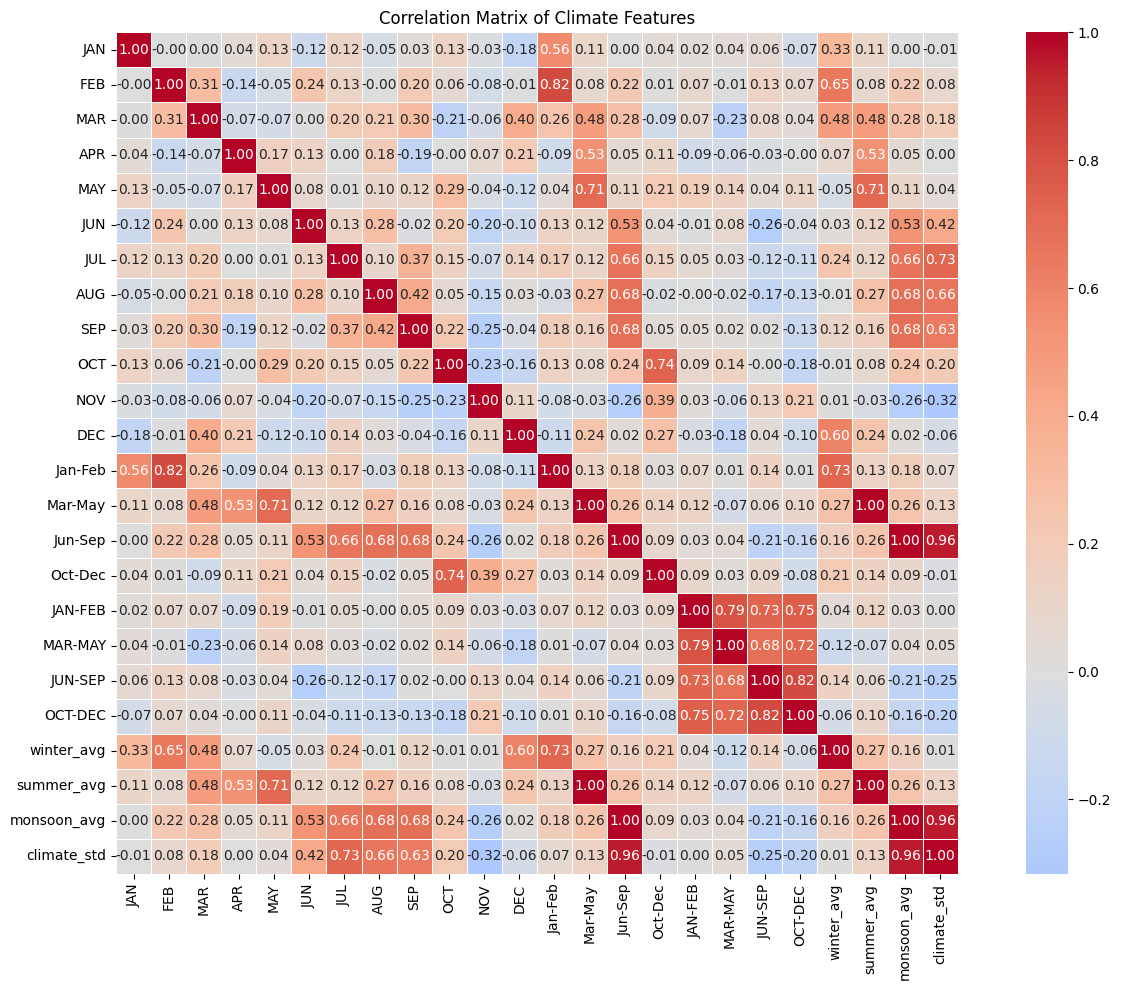


Highly correlated feature pairs (|corr| > 0.85):
     Feature 1    Feature 2  Correlation
0      Mar-May   summer_avg     0.999995
1      Jun-Sep  monsoon_avg     1.000000
2      Jun-Sep  climate_std     0.958340
3  monsoon_avg  climate_std     0.958369


In [20]:
# Separate features (exclude Year and any non-numeric columns)
feature_cols = [col for col in climate_df_clean.columns if col not in ['Year', 'ANNUAL']]
# Remove ANNUAL as it's already aggregated from other columns
feature_cols = [col for col in feature_cols if col != 'ANNUAL']

print(f"\nNumber of climate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Correlation matrix
corr_matrix = climate_df_clean[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85 or < -0.85)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated feature pairs (|corr| > {threshold}):")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())
else:
    print("No highly correlated pairs found.")

### ===================== 1. HANDLE HIGHLY CORRELATED FEATURES =====================

In [ ]:
# Your climate data
print("Original climate features:", climate_df_clean.columns.tolist())

# Identify the highly correlated features you found
high_corr_pairs = [
    ('Mar-May', 'summer_avg'),
    ('Jun-Sep', 'monsoon_avg'),
    ('Jun-Sep', 'climate_std'),
    ('monsoon_avg', 'climate_std')
]

In [ ]:
# Strategy: Keep the feature with higher variance or better interpretability
def handle_correlated_features(df, corr_threshold=0.85):
    """
    Remove highly correlated features, keeping the one with higher variance
    """
    # Calculate variance for each numeric feature
    variances = df.select_dtypes(include=[np.number]).var()

    # Get correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr()

    # Find pairs with correlation above threshold
    features_to_drop = set()
    correlated_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > corr_threshold:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                correlated_pairs.append((feat1, feat2))

                # Keep the feature with higher variance
                if variances[feat1] >= variances[feat2]:
                    features_to_drop.add(feat2)
                else:
                    features_to_drop.add(feat1)

    return features_to_drop, correlated_pairs

In [ ]:
# Apply the correlation handling
features_to_drop, correlated_pairs = handle_correlated_features(
    climate_df_clean,
    corr_threshold=0.85
)

print("\nFeatures to drop due to high correlation:")
print(features_to_drop)

In [ ]:
# Create a clean dataset without these features
climate_reduced = climate_df_clean.drop(columns=features_to_drop, errors='ignore')

print(f"\nOriginal features: {len(climate_df_clean.columns)}")
print(f"Features after removing correlated: {len(climate_reduced.columns)}")
print(f"Remaining features: {climate_reduced.columns.tolist()}")

In [ ]:
# ===================== 2. UPDATED FEATURE LIST =====================

# Get the remaining features (excluding Year and ANNUAL)
feature_cols = [col for col in climate_reduced.columns
                if col not in ['Year', 'ANNUAL']]

print(f"\nFeatures for analysis: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")

In [ ]:
# ===================== 3. CORRELATION ANALYSIS WITH REMAINING FEATURES =====================

# Correlation matrix of remaining features
corr_matrix_reduced = climate_reduced[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_reduced, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features (After Removing Highly Correlated)')
plt.tight_layout()
plt.show()

## ===================== 4. F-SCORE ANALYSIS WITH CLEANED DATA =====================

In [ ]:


# Prepare crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type']].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

# Select top crops with sufficient data
crop_counts = crop_data_clean.groupby('crop_type').size().sort_values(ascending=False)
top_crops = crop_counts.head(10).index.tolist()

print(f"\nAnalyzing top 10 crops: {top_crops}")

# Store results for all crops
all_feature_importance = {}

for crop in top_crops:
    crop_data = crop_data_clean[crop_data_clean['crop_type'] == crop]

    if len(crop_data) < 20:
        print(f"Skipping {crop} - insufficient data")
        continue

    # Merge with climate data
    merged_data = pd.merge(
        crop_data[['Year', 'Value']],
        climate_reduced,
        on='Year',
        how='inner'
    )

    if len(merged_data) < 10:
        print(f"Skipping {crop} - insufficient merged data")
        continue

    # Prepare features and target
    X = merged_data[feature_cols]
    y = merged_data['Value']

    # Handle missing values
    X = X.fillna(X.mean())

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    # F-score
    f_selector = SelectKBest(score_func=f_regression, k='all')
    f_selector.fit(X_scaled_df, y)

    f_scores = pd.DataFrame({
        'Feature': X.columns,
        'F_Score': f_selector.scores_,
        'p_value': f_selector.pvalues_
    })
    f_scores = f_scores.sort_values('F_Score', ascending=False)

    # Mutual Information
    mi_selector = SelectKBest(score_func=mutual_info_regression, k='all')
    mi_selector.fit(X_scaled_df, y)

    mi_scores = pd.DataFrame({
        'Feature': X.columns,
        'MI_Score': mi_selector.scores_
    })

    # Combine
    feature_importance = pd.merge(f_scores, mi_scores, on='Feature')
    all_feature_importance[crop] = feature_importance

    print(f"\nFeature importance for {crop} (Top 10):")
    print(feature_importance.head(10))

Original climate features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']

Features to drop due to high correlation:
{'summer_avg', 'climate_std', 'monsoon_avg'}

Original features: 26
Features after removing correlated: 23
Remaining features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg']

Features for analysis: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg']
Number of features: 21


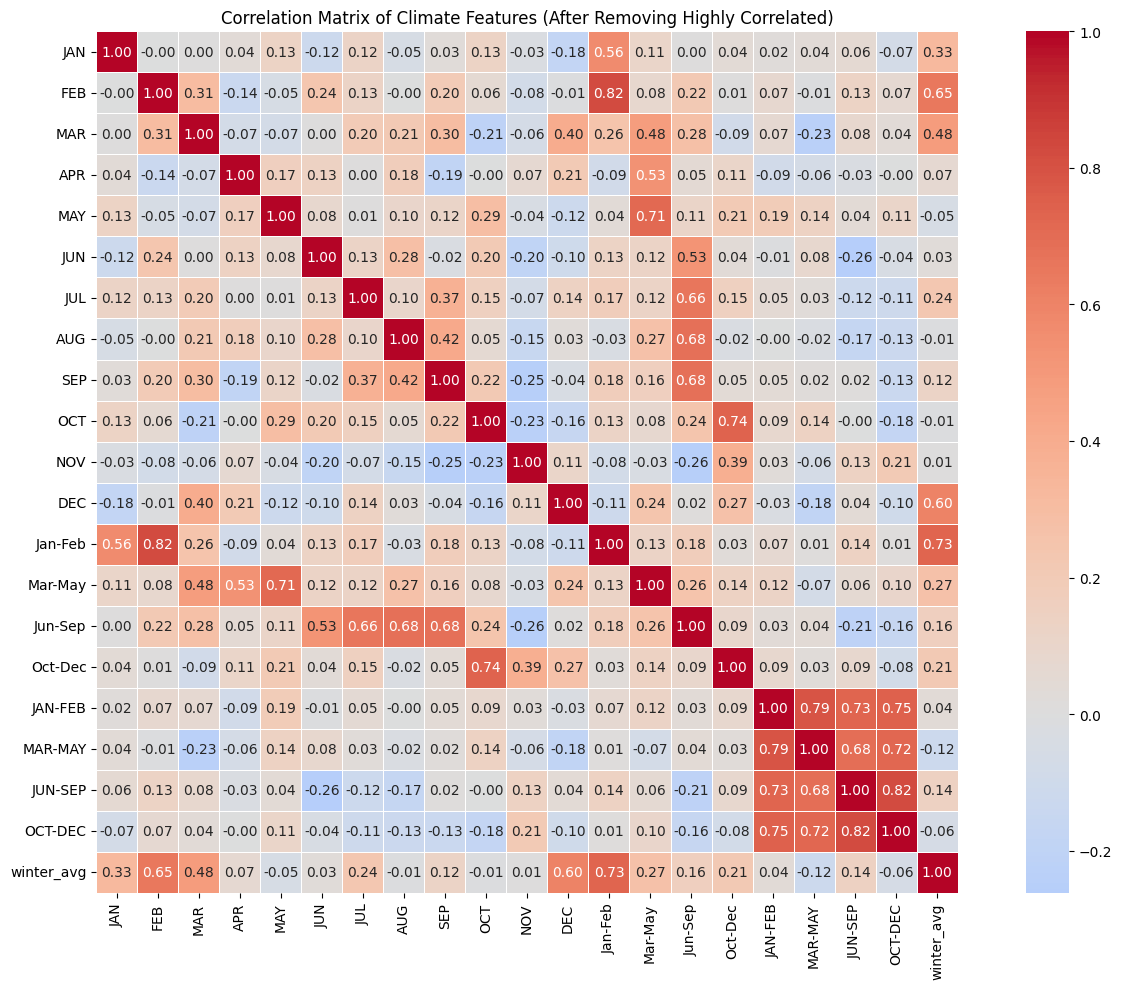


Analyzing top 10 crops: ['apples', 'apricots', 'areca nuts', 'bananas', 'barley', 'beans dry', 'beans green', 'cabbage', 'carrots', 'cashewnuts']

Feature importance for apples (Top 10):
   Feature    F_Score   p_value  MI_Score
0  OCT-DEC  17.144334  0.000054  0.095357
1  JUN-SEP  16.938098  0.000060  0.000000
2  JAN-FEB  12.926784  0.000423  0.025774
3  MAR-MAY  12.297871  0.000579  0.000000
4      DEC   0.687307  0.408231  0.000000
5      FEB   0.480891  0.488954  0.000000
6  Jan-Feb   0.269284  0.604479  0.000000
7      AUG   0.265363  0.607121  0.000000
8      JUL   0.230249  0.631949  0.000000
9      SEP   0.172119  0.678752  0.000000

Feature importance for apricots (Top 10):
      Feature   F_Score   p_value  MI_Score
0     MAR-MAY  0.442468  0.506825  0.000000
1     OCT-DEC  0.323625  0.570179  0.000000
2     Mar-May  0.287894  0.592267  0.000000
3     JAN-FEB  0.271393  0.603069  0.000000
4     JUN-SEP  0.216873  0.642022  0.000000
5  winter_avg  0.168779  0.681710  0.000000

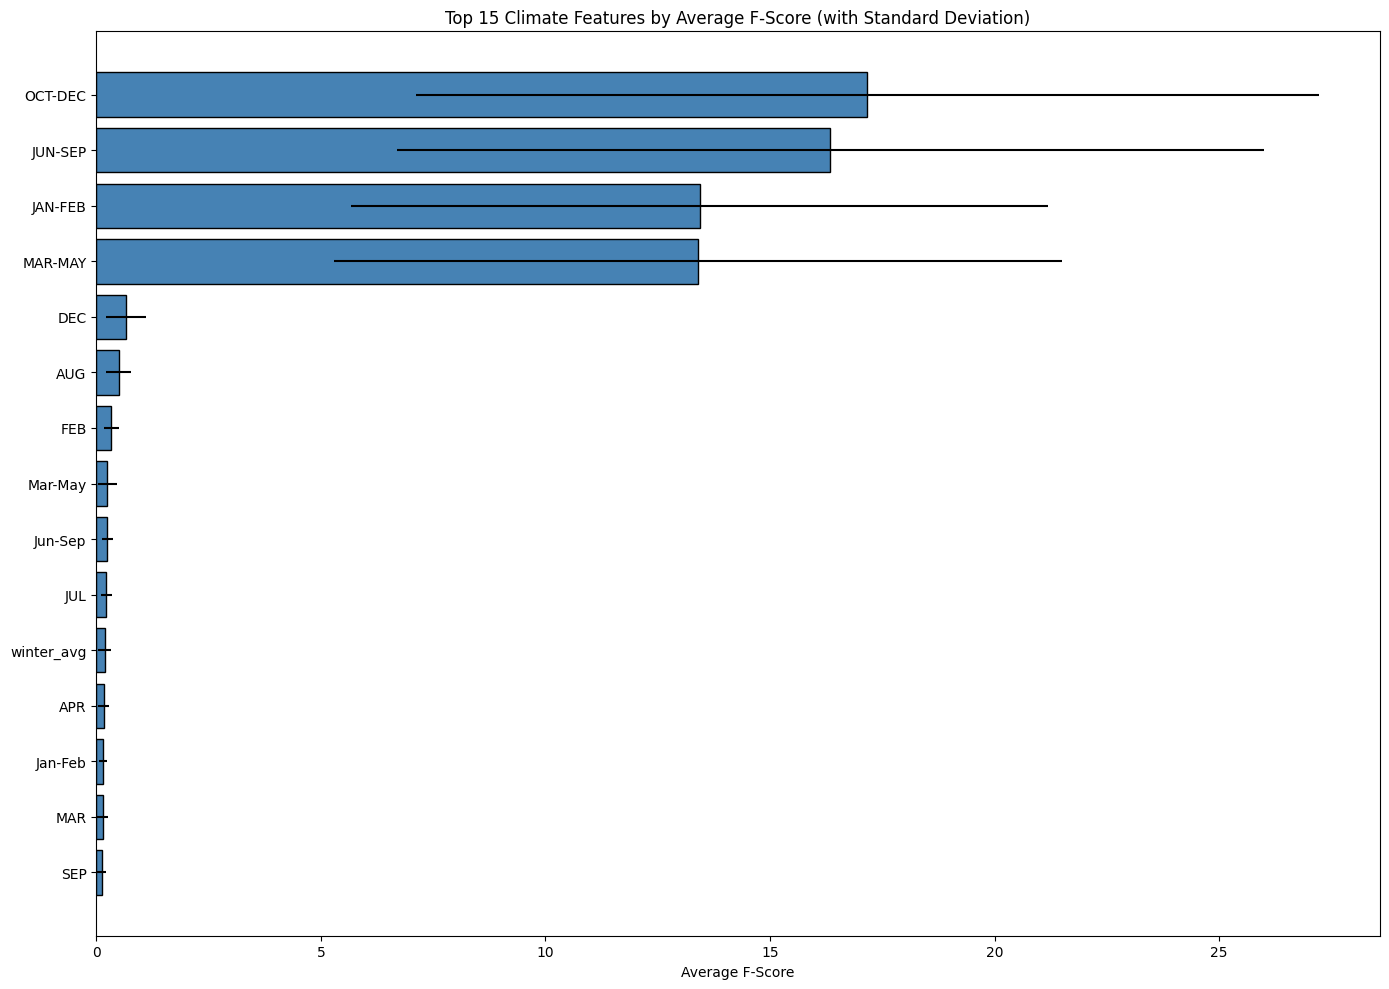


Features selected by F-score threshold (top 30%):
['OCT-DEC', 'JUN-SEP', 'JAN-FEB', 'MAR-MAY', 'DEC', 'AUG', 'FEB']
Number: 7

Final selected features (after correlation reduction):
['OCT-DEC', 'DEC', 'AUG', 'FEB']
Number: 4

Random Forest Feature Importance:
         Mean_RF_Importance
Feature                    
OCT-DEC            0.161737
JUN-SEP            0.110331
JAN-FEB            0.086400
MAR-MAY            0.072021
JUN                0.046291
Oct-Dec            0.043651
MAR                0.039806
Mar-May            0.039646
JAN                0.038163
AUG                0.035356
NOV                0.033638
DEC                0.032658
APR                0.032334
SEP                0.032118
MAY                0.031886

Final features after combining with RF: ['Mar-May', 'APR', 'MAY', 'FEB', 'JAN-FEB', 'AUG', 'Oct-Dec', 'OCT-DEC', 'JUN-SEP', 'MAR', 'SEP', 'NOV', 'DEC', 'JAN', 'MAR-MAY', 'JUN']
Total features: 16

Final climate dataset shape: (58, 17)
First 5 rows:
   Year  Mar-

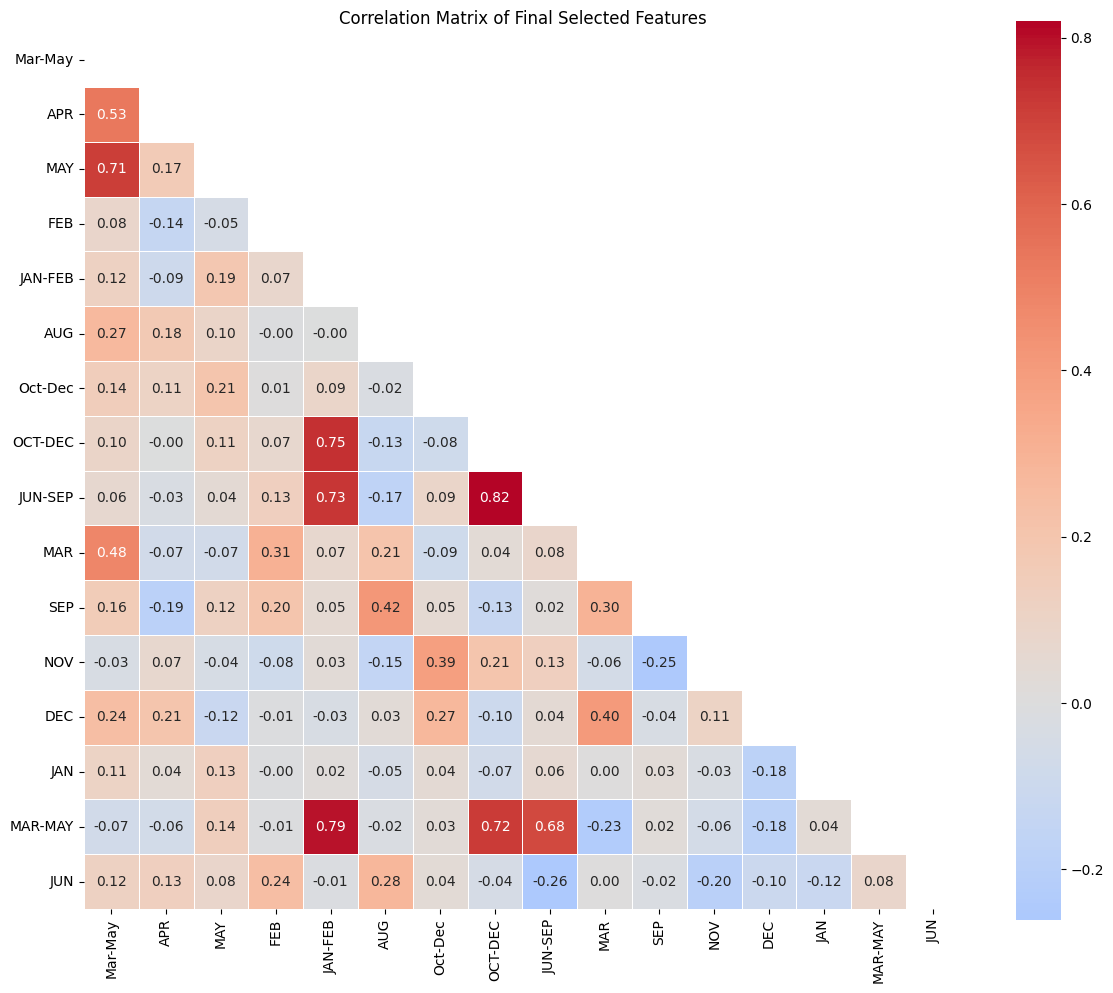


Feature selection completed successfully!


In [22]:

from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')







# ===================== 5. AGGREGATE FEATURE IMPORTANCE =====================

# Combine results across crops
if all_feature_importance:
    # Create dataframe with F-scores for each crop
    crop_features_df = pd.DataFrame()

    for crop, importance_df in all_feature_importance.items():
        temp = importance_df[['Feature', 'F_Score']].set_index('Feature')
        crop_features_df[f'{crop}_F_Score'] = temp['F_Score']

    # Fill NaN with 0
    crop_features_df = crop_features_df.fillna(0)

    # Calculate statistics
    crop_features_df['Mean_F_Score'] = crop_features_df.mean(axis=1)
    crop_features_df['Std_F_Score'] = crop_features_df.std(axis=1)
    crop_features_df['Max_F_Score'] = crop_features_df.max(axis=1)
    crop_features_df['Min_F_Score'] = crop_features_df.min(axis=1)
    crop_features_df['Rank_Mean'] = crop_features_df['Mean_F_Score'].rank(ascending=False)

    # Sort by mean F-score
    crop_features_df = crop_features_df.sort_values('Mean_F_Score', ascending=False)

    print("\n\n==================== OVERALL FEATURE IMPORTANCE ====================")
    print(crop_features_df[['Mean_F_Score', 'Std_F_Score', 'Rank_Mean']].head(20))

    # Visualize top features
    plt.figure(figsize=(14, 10))
    top_features = crop_features_df.head(15)
    plt.barh(top_features.index, top_features['Mean_F_Score'],
             xerr=top_features['Std_F_Score'] if not top_features['Std_F_Score'].isna().all() else None,
             color='steelblue', edgecolor='black')
    plt.xlabel('Average F-Score')
    plt.title('Top 15 Climate Features by Average F-Score (with Standard Deviation)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ===================== 6. SELECT FINAL FEATURES =====================

    # Method 1: Select features with high F-score
    threshold_mean = crop_features_df['Mean_F_Score'].quantile(0.70)  # Top 30%
    high_f_score_features = crop_features_df[
        crop_features_df['Mean_F_Score'] >= threshold_mean
    ].index.tolist()

    print(f"\nFeatures selected by F-score threshold (top 30%):")
    print(high_f_score_features)
    print(f"Number: {len(high_f_score_features)}")

    # Method 2: Select features with low correlation among themselves
    def select_low_correlation_features(features, df, corr_threshold=0.7):
        """
        Select features with low correlation among themselves
        """
        if len(features) == 0:
            return []

        # Get correlation matrix for these features
        corr_matrix = df[features].corr()

        selected = []
        for feature in features:
            if not selected:
                selected.append(feature)
            else:
                # Check if feature is correlated with any selected feature
                correlated = False
                for sel in selected:
                    if abs(corr_matrix.loc[feature, sel]) > corr_threshold:
                        correlated = True
                        break
                if not correlated:
                    selected.append(feature)
        return selected

    # Select features based on F-score first, then reduce correlation
    final_features = select_low_correlation_features(
        high_f_score_features,
        climate_reduced,
        corr_threshold=0.7
    )

    print(f"\nFinal selected features (after correlation reduction):")
    print(final_features)
    print(f"Number: {len(final_features)}")

    # ===================== 7. RANDOM FOREST FEATURE IMPORTANCE (Optional) =====================

    # Use Random Forest as an alternative method
    rf_importance = {}

    for crop in top_crops[:5]:  # Use first 5 crops for RF
        crop_data = crop_data_clean[crop_data_clean['crop_type'] == crop]

        if len(crop_data) < 20:
            continue

        merged_data = pd.merge(
            crop_data[['Year', 'Value']],
            climate_reduced,
            on='Year',
            how='inner'
        )

        if len(merged_data) < 10:
            continue

        X = merged_data[feature_cols].fillna(0)
        y = merged_data['Value']

        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)

        importance = pd.DataFrame({
            'Feature': X.columns,
            'RF_Importance': rf.feature_importances_
        }).sort_values('RF_Importance', ascending=False)

        rf_importance[crop] = importance

    # Aggregate RF importance
    if rf_importance:
        rf_importance_df = pd.DataFrame()

        for crop, importance_df in rf_importance.items():
            temp = importance_df[['Feature', 'RF_Importance']].set_index('Feature')
            rf_importance_df[f'{crop}_RF'] = temp['RF_Importance']

        rf_importance_df = rf_importance_df.fillna(0)
        rf_importance_df['Mean_RF_Importance'] = rf_importance_df.mean(axis=1)
        rf_importance_df = rf_importance_df.sort_values('Mean_RF_Importance', ascending=False)

        print("\nRandom Forest Feature Importance:")
        print(rf_importance_df[['Mean_RF_Importance']].head(15))

        # Combine with F-score selection
        rf_top_features = rf_importance_df.head(15).index.tolist()
        final_features = list(set(final_features) | set(rf_top_features))

        print(f"\nFinal features after combining with RF: {final_features}")
        print(f"Total features: {len(final_features)}")

# ===================== 8. CREATE FINAL CLIMATE DATASET =====================

# Create final dataset with selected features
climate_final = climate_reduced[['Year'] + final_features].copy()

print(f"\nFinal climate dataset shape: {climate_final.shape}")
print("First 5 rows:")
print(climate_final.head())

# Save the final dataset
climate_final.to_csv('climate_data_selected_features.csv', index=False)
print("\nSaved final climate dataset to 'climate_data_selected_features.csv'")

# ===================== 9. SUMMARY STATISTICS =====================

print("\n==================== SUMMARY ====================")
print(f"Original features (excluding Year): {len(climate_df_clean.columns) - 1}")
print(f"Features after removing correlated: {len(feature_cols)}")
print(f"Features selected by F-score: {len(high_f_score_features)}")
print(f"Final selected features: {len(final_features)}")
print(f"Reduction: {len(climate_df_clean.columns) - 1 - len(final_features)} features")
print(f"Reduction percentage: {((len(climate_df_clean.columns) - 1 - len(final_features)) / (len(climate_df_clean.columns) - 1) * 100):.1f}%")

print(f"\nFinal selected features:\n{final_features}")

# ===================== 10. VISUALIZATION OF CORRELATIONS =====================

# Plot correlation matrix of final features
if len(final_features) > 1:
    plt.figure(figsize=(12, 10))
    final_corr = climate_final[final_features].corr()

    # Mask upper triangle
    mask = np.triu(np.ones_like(final_corr, dtype=bool))

    sns.heatmap(final_corr, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5, square=True)
    plt.title('Correlation Matrix of Final Selected Features')
    plt.tight_layout()
    plt.show()

print("\nFeature selection completed successfully!")

In [17]:
# ============================================================
# CORRELATION-BASED FEATURE SELECTION FOR CLIMATE DATA
# ============================================================

# 1. Select numerical climate features
climate_numeric = climate_df.select_dtypes(include=[np.number]).copy()

# Remove Year because it is a time identifier, not a climate variable
if 'Year' in climate_numeric.columns:
    climate_numeric = climate_numeric.drop(columns=['Year'])

print("Original climate features:")
print(climate_numeric.columns.tolist())
print("Number of features:", len(climate_numeric.columns))




Original climate features:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']
Number of features: 25


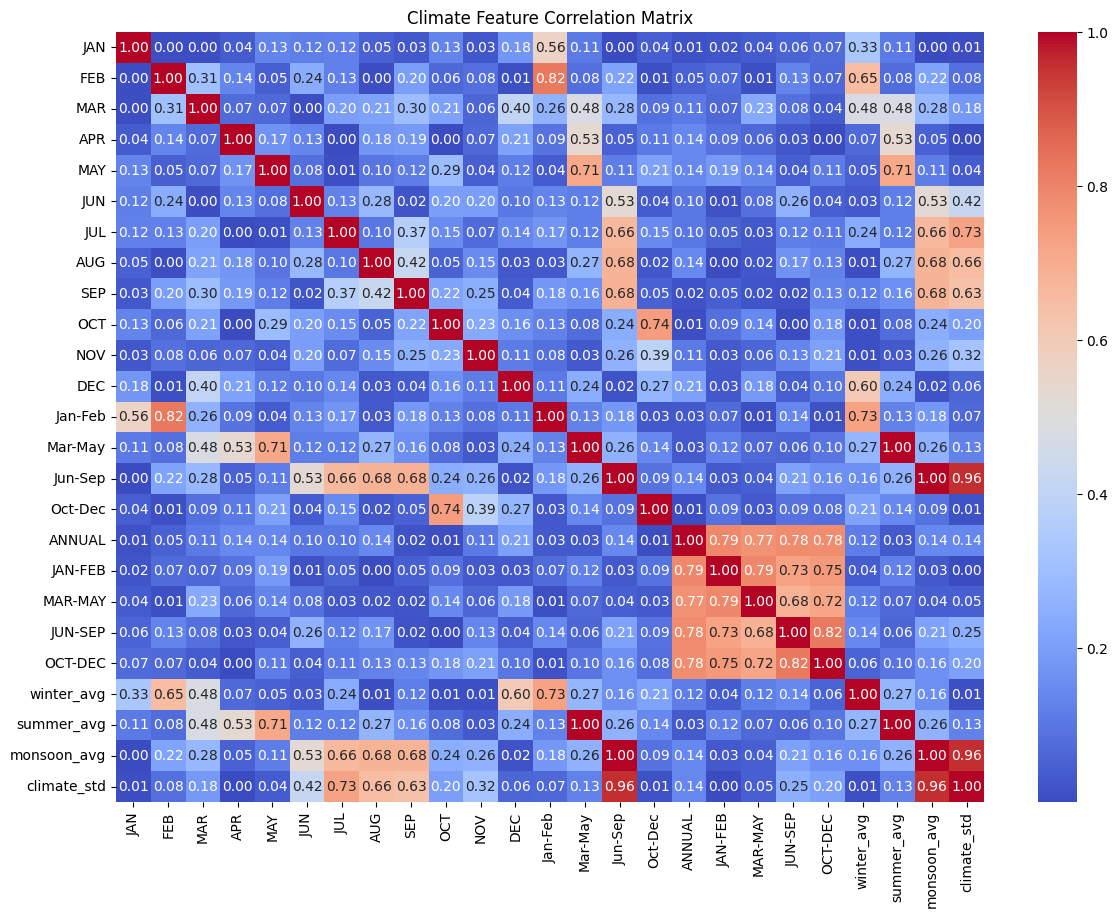


Highly correlated features to remove:
['summer_avg', 'monsoon_avg', 'climate_std']

Selected climate features:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg']

Number of selected climate features: 22

Final climate dataset:
   Year   JAN   FEB   MAR   APR   MAY    JUN    JUL    AUG    SEP  ...  \
0  1961  26.1  34.8  26.0  28.5  77.6  192.9  336.6  287.6  234.9  ...   
1  1962  12.6  21.6  16.0  43.6  70.8  137.1  281.6  276.9  211.0  ...   
2  1963   6.8   9.8  41.7  50.6  60.9  168.0  258.6  316.7  164.9  ...   
3  1964  18.6  14.1  19.0  40.0  52.1  177.2  345.7  273.7  200.4  ...   
4  1965  11.8  28.1  26.7  45.1  52.7  116.1  270.1  192.8  129.5  ...   

   Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  \
0     60.9    132.1   1052.0    154.2   24.00    18.98    26.11    27.06   
1     34.3    130.4    906.6 

In [18]:
# ============================================================
# 2. Correlation Matrix
# ============================================================

corr_matrix = climate_numeric.corr().abs()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Climate Feature Correlation Matrix")
plt.show()


# ============================================================
# 3. Remove highly correlated features
# ============================================================

correlation_threshold = 0.85

# Look only at upper triangle
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features having correlation > threshold
to_drop = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

print("\nHighly correlated features to remove:")
print(to_drop)


# ============================================================
# 4. Create selected climate features
# ============================================================

selected_climate_features = [
    column
    for column in climate_numeric.columns
    if column not in to_drop
]

print("\nSelected climate features:")
print(selected_climate_features)

print(
    "\nNumber of selected climate features:",
    len(selected_climate_features)
)


# ============================================================
# 5. Final climate dataset for clustering
# ============================================================

climate_selected = climate_df[
    ['Year'] + selected_climate_features
].copy()

print("\nFinal climate dataset:")
print(climate_selected.head())

print("\nShape:", climate_selected.shape)

#Prepare Features for Unsupervised Learning

In [19]:
# Select only numerical features for unsupervised learning
numerical_features = climate_df.select_dtypes(include=[np.number]).columns.tolist()
# numerical_features.remove('target_yield')

# # Remove Year if it's not meaningful for clustering
# if 'Year' in numerical_features:
#     numerical_features.remove('Year')

print(f"Numerical features for clustering: {numerical_features}")

X = climate_df[numerical_features].copy()

# Handle missing values
if X.isnull().any().any():
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print(f"Missing values handled: {X.isnull().sum().sum()} remaining")

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Final feature matrix shape: {X_scaled_df.shape}")

Numerical features for clustering: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']
Final feature matrix shape: (58, 26)


In [20]:
X_scaled_df

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,Oct-Dec,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,-1.702441,1.483537,1.243844,-0.247470,-1.009677,1.098847,0.862262,1.480892,0.983885,2.159378,...,1.263655,-1.264155,-0.782054,-0.324238,-0.857215,-1.717277,1.080497,0.135009,2.144477,1.885730
1,-1.642706,-0.673584,-0.201205,-1.107459,0.566290,0.611843,-0.929241,-0.019758,0.643206,1.379946,...,0.233747,-1.154311,-0.873530,-0.608528,-0.642333,-1.216680,0.557651,0.052786,0.395192,0.395300
2,-1.582971,-1.600347,-1.492990,1.102715,1.296870,-0.097179,0.062828,-0.647302,1.910405,-0.123477,...,0.840456,-0.852239,-0.664441,-1.091820,-0.454310,-0.265546,-1.766105,1.155541,0.414442,0.506650
3,-1.523237,0.285137,-1.022255,-0.849462,0.190563,-0.727420,0.358201,1.729181,0.541321,1.034257,...,-0.635120,-0.989545,-0.978074,0.059554,-1.286981,-1.033128,-0.756723,-0.880686,1.482781,1.777038
4,-1.463502,-0.801413,0.510372,-0.187270,0.722843,-0.684449,-1.603463,-0.333530,-2.034468,-1.277949,...,-1.724950,-1.071928,-0.468421,-1.560899,-0.803495,-0.165427,0.412417,-0.232576,-1.988117,-1.659473
5,-1.403767,-0.593690,0.214794,-0.737664,-0.790503,-0.362166,0.409570,-0.813738,-1.407237,-0.808333,...,0.121393,-0.275557,0.459409,-0.381096,-0.561752,-0.615964,-0.088643,-1.025785,-1.035275,-1.342119
6,-1.344032,-0.913264,-1.011308,2.960293,-0.905308,-1.393470,-0.707711,0.635071,0.242033,0.052629,...,-0.432884,-0.962084,-0.180925,-1.120249,-0.508031,-0.866262,1.813932,0.304292,0.125702,0.354579
7,-1.284298,2.010834,-0.398257,-0.118471,-0.581765,-1.114159,-0.527919,0.752395,-1.397685,-1.277949,...,-0.706278,-1.428922,-1.736019,-1.020748,-0.427450,-0.849576,0.390631,-1.088661,-0.865640,-0.432586
8,-1.224563,-0.657605,-0.978466,-0.754864,0.159252,0.081867,-1.150771,0.967942,0.531769,0.130899,...,-0.638865,-0.000947,-0.520693,0.073768,-0.078265,0.001438,-1.199689,-0.295452,0.244807,0.779528
9,-1.164828,1.020156,0.422794,-0.256069,-0.936619,0.533063,1.600695,-1.002001,1.792600,1.435387,...,-1.043338,-0.550168,-0.024108,0.073768,-0.857215,-1.083188,-0.313757,-0.218066,1.364878,1.162460


In [21]:
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         58 non-null     int64  
 1   JAN          58 non-null     float64
 2   FEB          58 non-null     float64
 3   MAR          58 non-null     float64
 4   APR          58 non-null     float64
 5   MAY          58 non-null     float64
 6   JUN          58 non-null     float64
 7   JUL          58 non-null     float64
 8   AUG          58 non-null     float64
 9   SEP          58 non-null     float64
 10  OCT          58 non-null     float64
 11  NOV          58 non-null     float64
 12  DEC          58 non-null     float64
 13  Jan-Feb      58 non-null     float64
 14  Mar-May      58 non-null     float64
 15  Jun-Sep      58 non-null     float64
 16  Oct-Dec      58 non-null     float64
 17  ANNUAL       58 non-null     float64
 18  JAN-FEB      58 non-null     float64
 19  MAR-MAY   

In [22]:
climate_df

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,Oct-Dec,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,...,154.2,24.00,18.98,26.11,27.06,21.17,23.766667,44.033333,263.000,116.831600
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,...,126.7,24.04,18.91,25.91,27.14,21.47,21.366667,43.466667,226.650,102.202809
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,...,142.9,24.15,19.07,25.57,27.21,22.04,10.700000,51.066667,227.050,103.295723
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,...,103.5,24.10,18.83,26.38,26.90,21.58,15.333333,37.033333,249.250,115.764773
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,...,74.4,24.07,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125,82.034909
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,...,123.7,24.36,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925,85.149784
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,...,108.9,24.11,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050,101.803130
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,...,101.6,23.94,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450,94.076981
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,...,103.4,24.46,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525,105.974065
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,...,92.6,24.26,19.56,26.39,27.06,21.55,17.366667,41.600000,246.800,109.732596
